# 3- Exploring some of the features to be used

- Fixations: count, duration (mean/std/max/min)
- Saccades: count, peak_veocity, amplitude (mean/max/min/std), duration (mean/std/max/min)
- Blinks: count, mean duration
- Pupil: LHIPA 

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [3]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 5082 records at 120 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3557 records at 120 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Ther

In [4]:
# Lets check integrity of the data
display(all_eye_data.columns)
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

Index(['timestamp_sec', 'eye_id', 'pupil_diameter_px', 'confidence',
       'norm_pos_x', 'norm_pos_y', 'gaze_point_3d_x', 'gaze_point_3d_y',
       'gaze_point_3d_z', 'subject_id', 'task_id', 'cl_class'],
      dtype='str')

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [ ]:
import tqdm

reload(cwfeat)
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 600 # 5 seconds at 60Hz
WINDOW_STEP = 120
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

n_skipped_windows = 0

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            n_skipped_windows += 1
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=45, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)
    # if subject_id > 5:
    #     break

print(f"Extracted features for {len(features_df)} windows.")
print(f"Skipped {n_skipped_windows} windows due to low confidence percentage.")

Extracting features: 100%|██████████| 184/184 [06:16<00:00,  2.05s/it]

Extracted features for 3192 windows.
Skipped 296 windows due to low confidence percentage.


In [86]:
# Check what is the issue with the NaNs
display(features_df[features_df.isna().any(axis=1)].head())
print(f"Dropping {features_df.isna().any(axis=1).sum()} rows with NaN values.")
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True)

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id,cl_class
712,4,2446.3225,3684.07,416.75,-1.410833,2.153521,1427.817370,3,46.557093,104.208864,...,16.670000,0,0.00,0.00,4.106024,0.001557,8.000000,12,4,high
713,4,2450.4900,3283.99,1233.58,-0.741022,-1.653764,948.775409,3,46.557093,104.208864,...,19.248858,0,0.00,0.00,4.206170,0.001776,8.500000,12,4,high
1753,4,2242.1150,5134.36,83.35,0.574044,-2.278743,2324.912255,3,45.796837,396.547911,...,187.861359,6,283.39,150.03,3.485218,0.009085,6.666667,27,3,high


Dropping 3 rows with NaN values.


Let's check the distribtuion of the label classes 

<Axes: title={'center': 'Distribution of classes'}, xlabel='Cognitive Load Class', ylabel='Number of windows'>

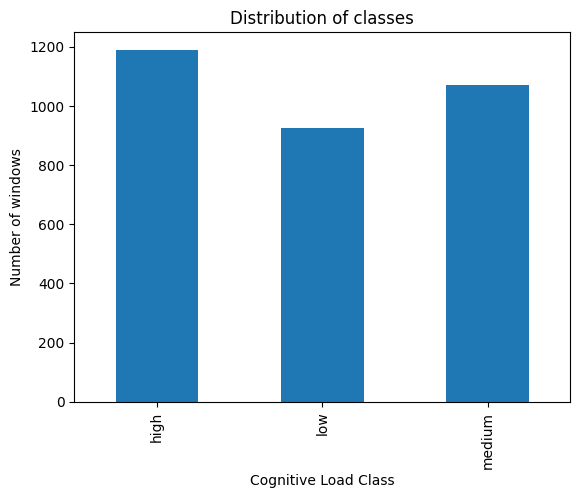

In [87]:
features_df_transformed.groupby('cl_class').count().plot(kind='bar', y='subject_id', title="Distribution of classes", legend=False, ylabel="Number of windows", xlabel="Cognitive Load Class")

As one can see, classes look quite balanced, which is a good thing for training a classifier.

Let's also look at the distribution of class labels w.r.t the task id (A1 < A2 < A3 < A4)

<Axes: title={'center': 'Distribution of classes within each task'}, xlabel='Task ID and Cognitive Load Class', ylabel='Number of windows'>

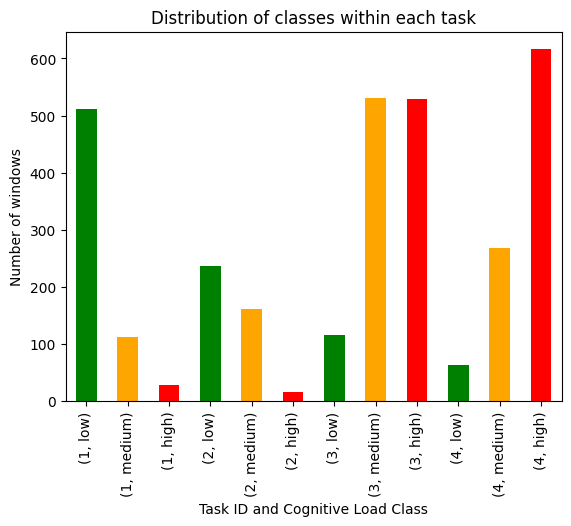

In [125]:
# Distribution of classes within each task and make sure class is from low to high
features_df_transformed['cl_class'] = pd.Categorical(features_df_transformed['cl_class'], categories=['low', 'medium', 'high'], ordered=True)
features_df_transformed.groupby(['task_id', 'cl_class']).count().plot(kind='bar', y='subject_id', title="Distribution of classes within each task",legend=False, ylabel="Number of windows", xlabel="Task ID and Cognitive Load Class", color=['green', 'orange', 'red'])

subject_id    97
dtype: int64

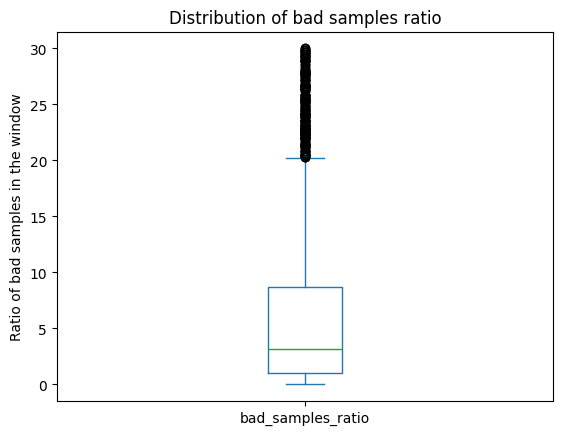

In [88]:
# Bad samples
# features_df_transformed.plot(kind='hist', y='bad_samples_ratio', bins=50, title="Distribution of bad samples ratio", xlabel="Ratio of bad samples in the window", ylabel="Count of windows")
features_df_transformed.plot(kind='box', y='bad_samples_ratio', title="Distribution of bad samples ratio", ylabel="Ratio of bad samples in the window")
features_df_transformed.loc[features_df_transformed['bad_samples_ratio'] > 25, ['subject_id']].count()

Now let's explore the distribution of the LHIPA metric.

As a reminder, it is related to a count of the number of spike/sec over the defined time window

In [89]:
features_df_transformed['pupil_lhipa'].describe()

count    3189.000000
mean        4.472014
std         0.520421
min         2.203232
25%         4.206170
50%         4.558674
75%         4.807052
max         5.708374
Name: pupil_lhipa, dtype: float64

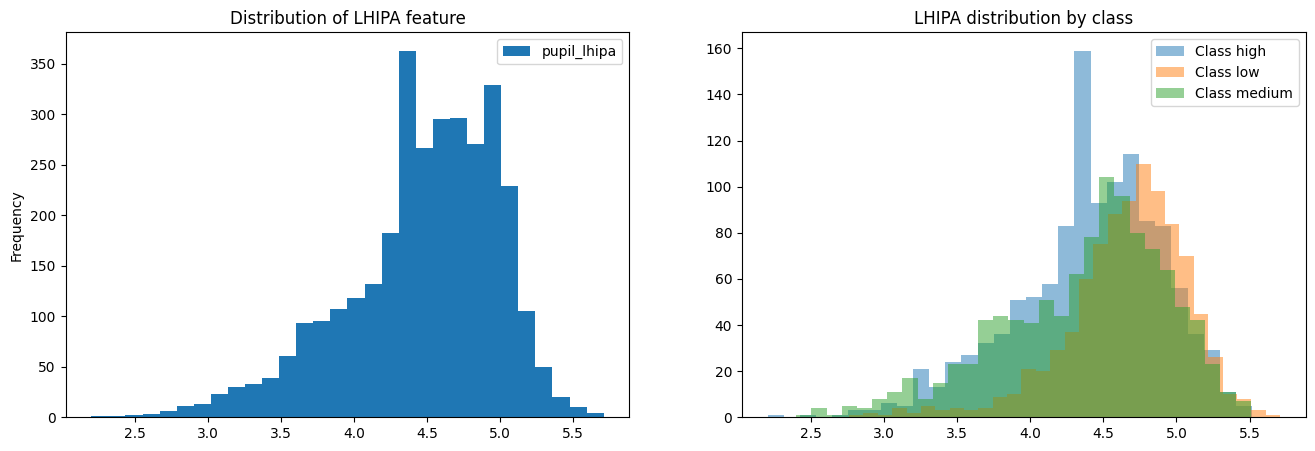

In [90]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
features_df_transformed.plot(y='pupil_lhipa', kind='hist', bins=30, title='Distribution of LHIPA feature', ax=axs[0])
grouped_df = features_df_transformed.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[1].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[1].set_title('LHIPA distribution by class')
axs[1].legend()

<Axes: title={'center': 'pupil_lhipa'}, xlabel='Cognitive Load Class', ylabel='LHIPA'>

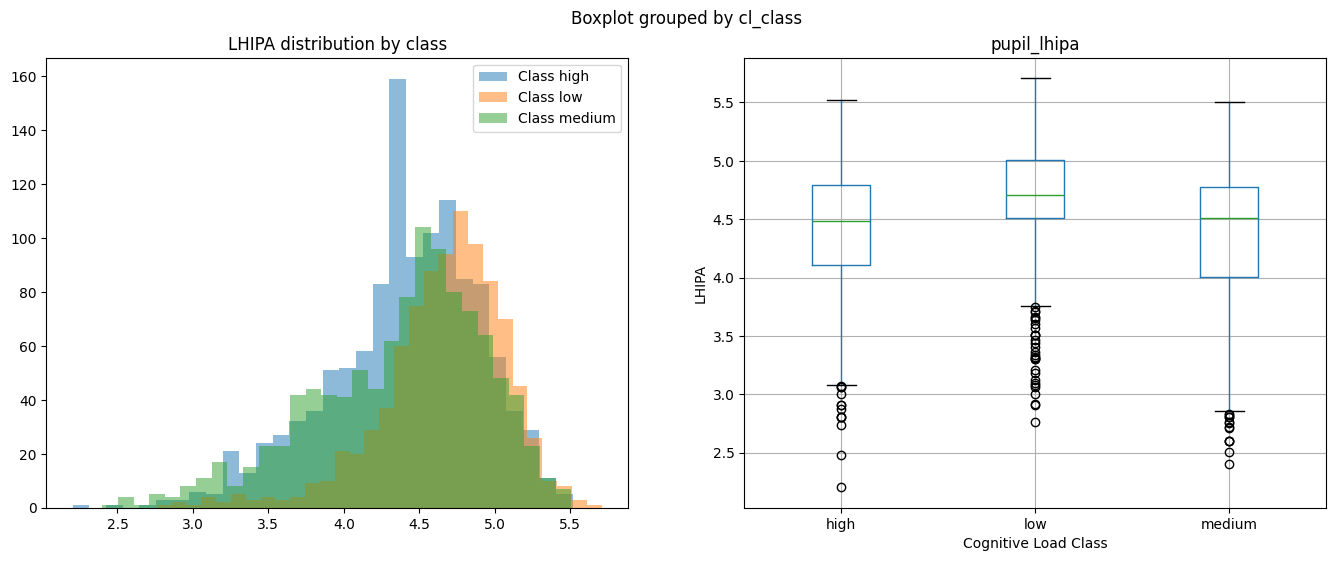

In [91]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df_transformed.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[0].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[0].legend()
axs[0].set_title('LHIPA distribution by class')
features_df_transformed.boxplot(column='pupil_lhipa', by='cl_class', ax=axs[1], ylabel='LHIPA', xlabel='Cognitive Load Class')


In [92]:
# Lets perform a ttest to see if the difference in LHIPA between classes is significant
from scipy.stats import ttest_ind
class_0 = features_df_transformed[features_df_transformed['cl_class'] == 'low']['pupil_lhipa']
class_1 = features_df_transformed[features_df_transformed['cl_class'] == 'medium']['pupil_lhipa']
class_2 = features_df_transformed[features_df_transformed['cl_class'] == 'high']['pupil_lhipa']
print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")

Number of windows in low class: 927, medium class: 1072, high class: 1190
T-test between low and medium classes: t-statistic=14.834, p-value=0.00000
T-test between low and high classes: t-statistic=14.185, p-value=0.00000
T-test between medium and high classes: t-statistic=-1.774, p-value=0.07622


Let's take a look at the Cohen's d effect size metric.

It tells you how much is the mean difference between two distributions in terms of std multiplier.
For example, if $C_d\approx 0.5$, then it means that the two distribution means are different at a scale of 0.5 the std.

| $C_d$ coeff | effect size |
|-------------|-------------|
| 0.2 | small
| 0.5 | Medium
| 0.8 | Large

In [93]:
# Cohen's d effect size
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(y) - np.mean(x)) / pooled_std if pooled_std > 0 else 0

d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")


Cohen's d effect size between low and medium classes: -0.653
Cohen's d effect size between low and high classes: -0.609
Cohen's d effect size between medium and high classes: 0.075


#### What about this new RIPA2 "real-time" pupil frequency metric

In [94]:
features_df_transformed['pupil_ripa2'].describe()

count    3189.000000
mean        0.004250
std         0.003789
min         0.000363
25%         0.001972
50%         0.003365
75%         0.005301
max         0.043860
Name: pupil_ripa2, dtype: float64

<Axes: title={'center': 'pupil_ripa2'}, xlabel='Cognitive Load Class', ylabel='RIPA2'>

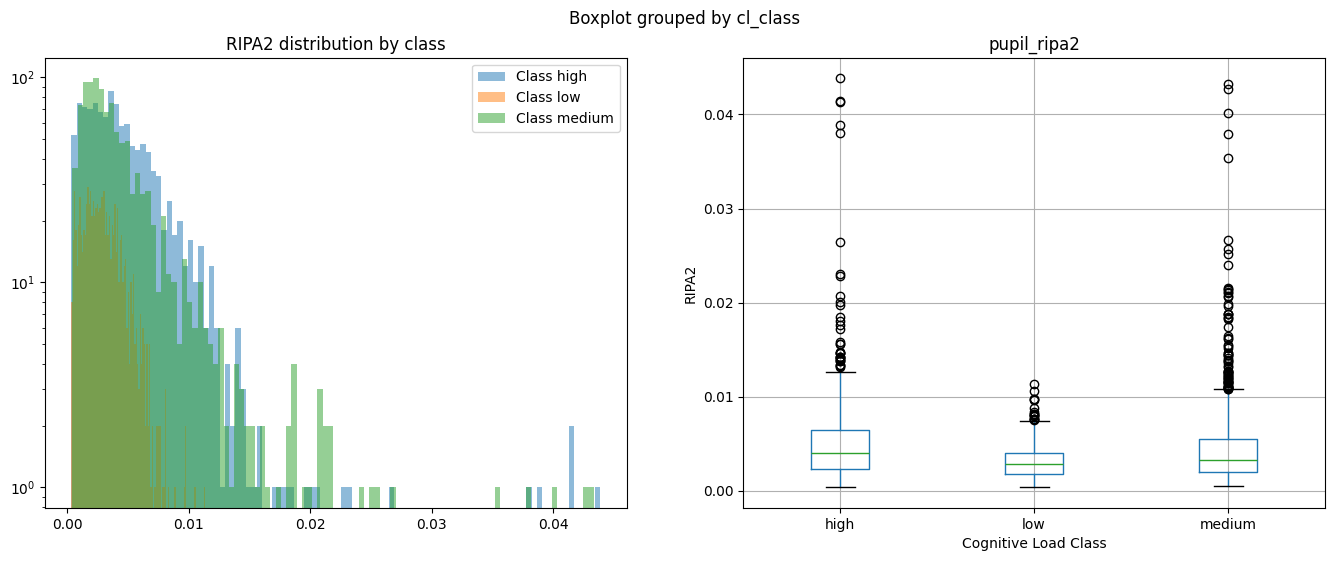

In [95]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    x = group['pupil_ripa2']
    axs[0].hist(x, bins=100, alpha=0.5, label=f'Class {cl_class}', log=True)
axs[0].legend()
axs[0].set_title('RIPA2 distribution by class')
features_df.boxplot(column='pupil_ripa2', by='cl_class', ax=axs[1], ylabel='RIPA2', xlabel='Cognitive Load Class')


In [96]:
class_0 = features_df_transformed[features_df_transformed['cl_class'] == 'low']['pupil_ripa2']
class_1 = features_df_transformed[features_df_transformed['cl_class'] == 'medium']['pupil_ripa2']
class_2 = features_df_transformed[features_df_transformed['cl_class'] == 'high']['pupil_ripa2']

print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")

Number of windows in low class: 927, medium class: 1072, high class: 1190
T-test between low and medium classes: t-statistic=-10.459, p-value=0.00000
T-test between low and high classes: t-statistic=-14.386, p-value=0.00000
T-test between medium and high classes: t-statistic=-1.995, p-value=0.04620
Cohen's d effect size between low and medium classes: 0.445
Cohen's d effect size between low and high classes: 0.578
Cohen's d effect size between medium and high classes: 0.084


#### What about the distributions of the fixations metric?

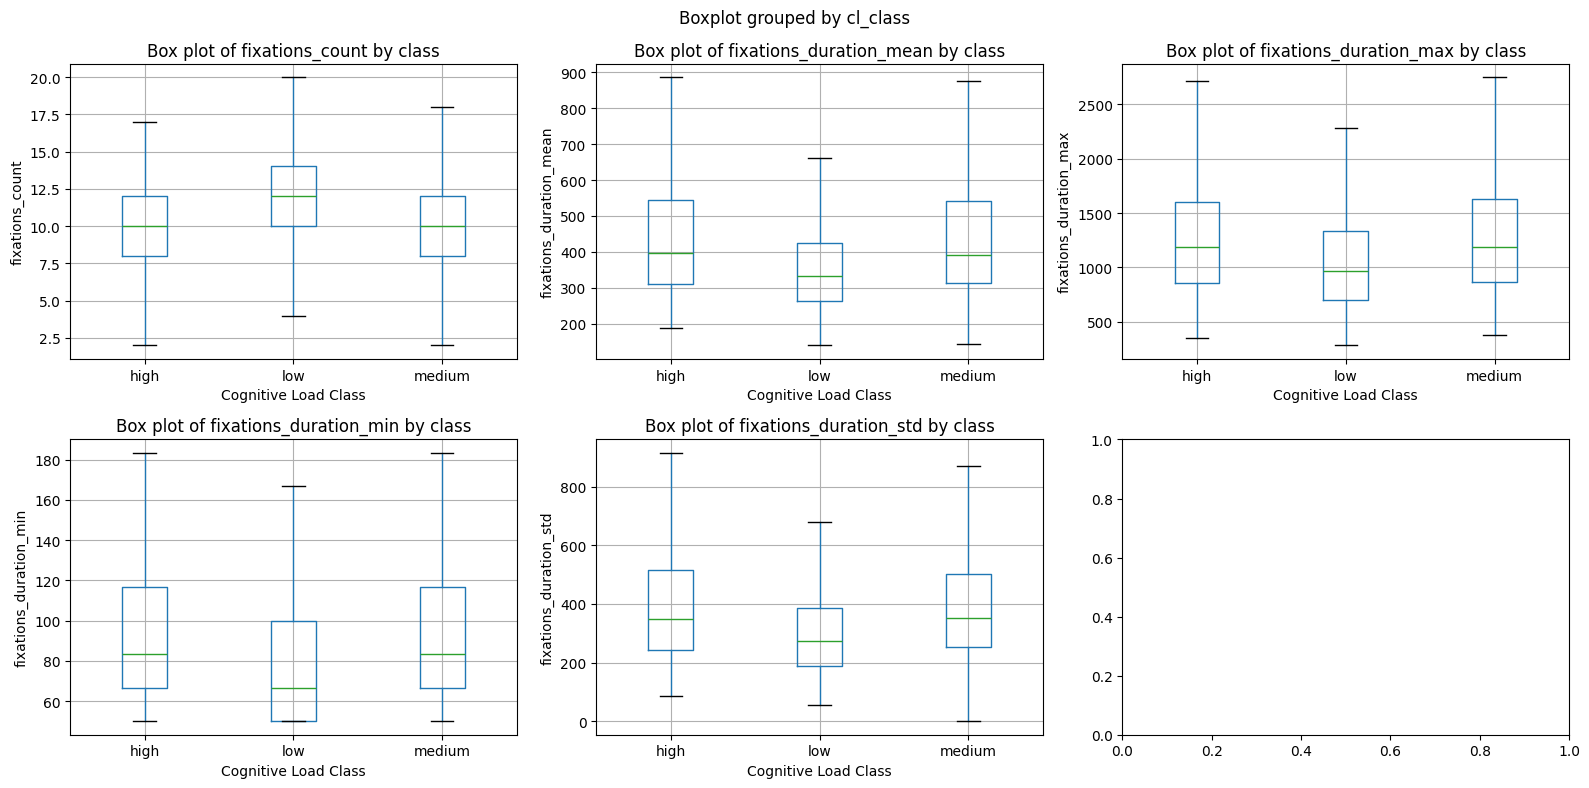

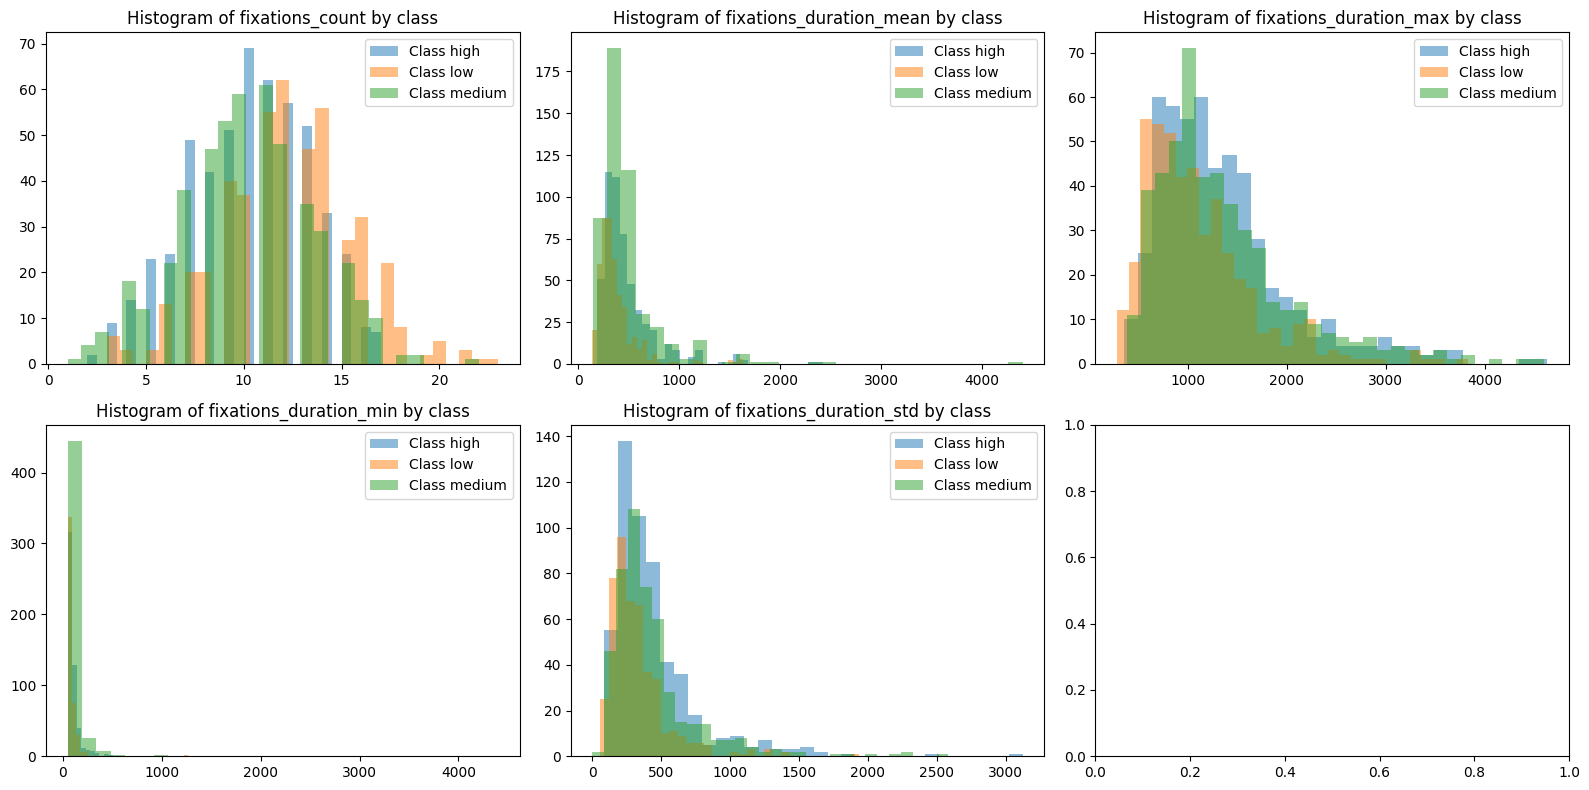

In [21]:
fixation_cols = [col for col in features_df.columns if col.startswith('fixations_')]
# Box plot for all fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    features_df.boxplot(column=col, by='cl_class', ax=axs[i], ylabel=col, xlabel='Cognitive Load Class', showfliers=False)
    axs[i].set_title(f'Box plot of {col} by class')

# Also plot histograms of the fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    for cl_class, group in features_df.groupby('cl_class'):
        axs[i].hist(group[col], bins=30, alpha=0.5, label=f'Class {cl_class}')
    axs[i].set_title(f'Histogram of {col} by class')
    axs[i].legend()

#### Saccades distributions

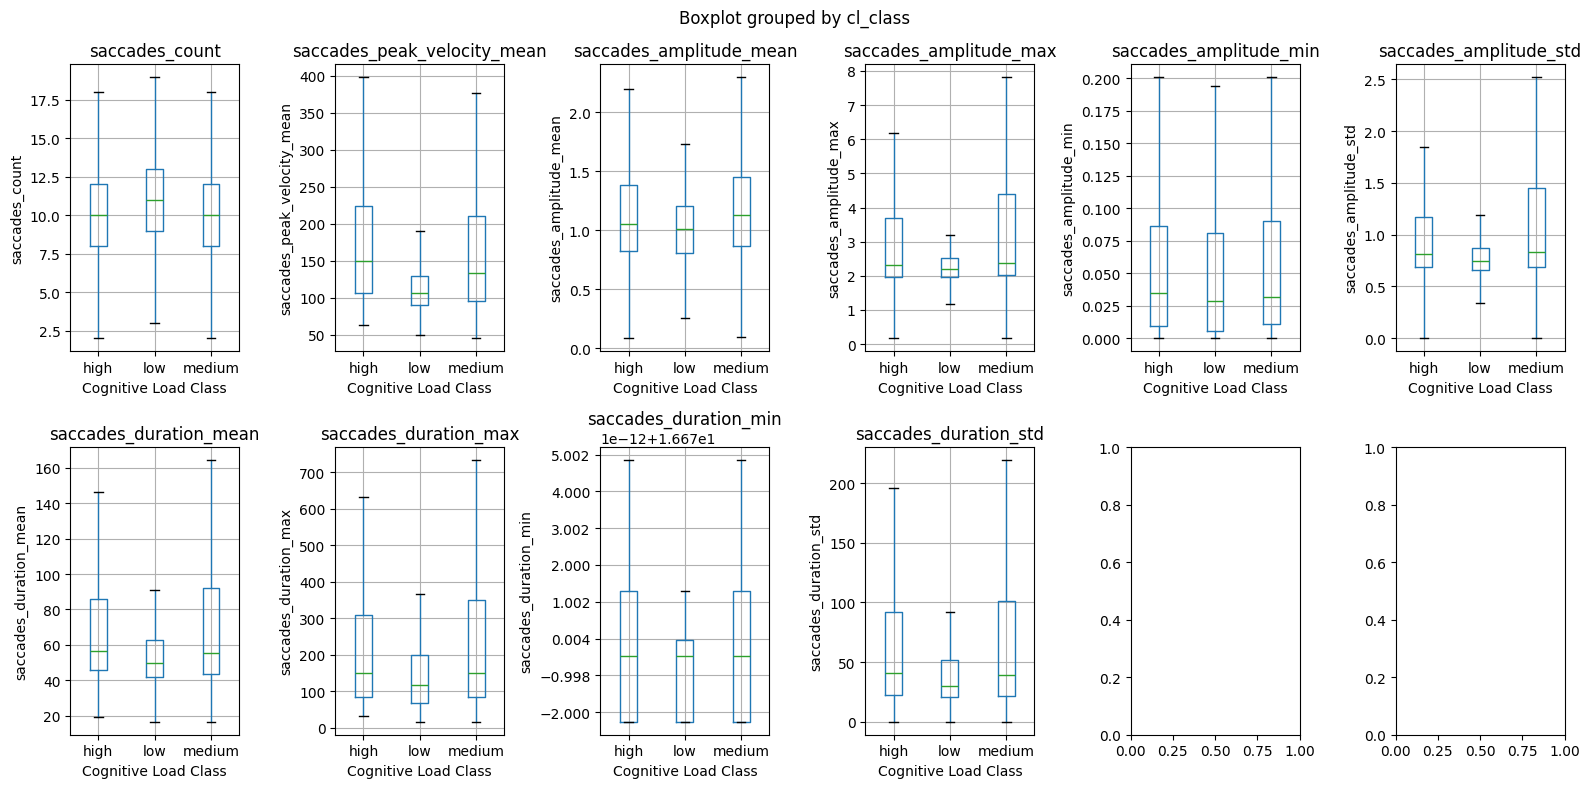

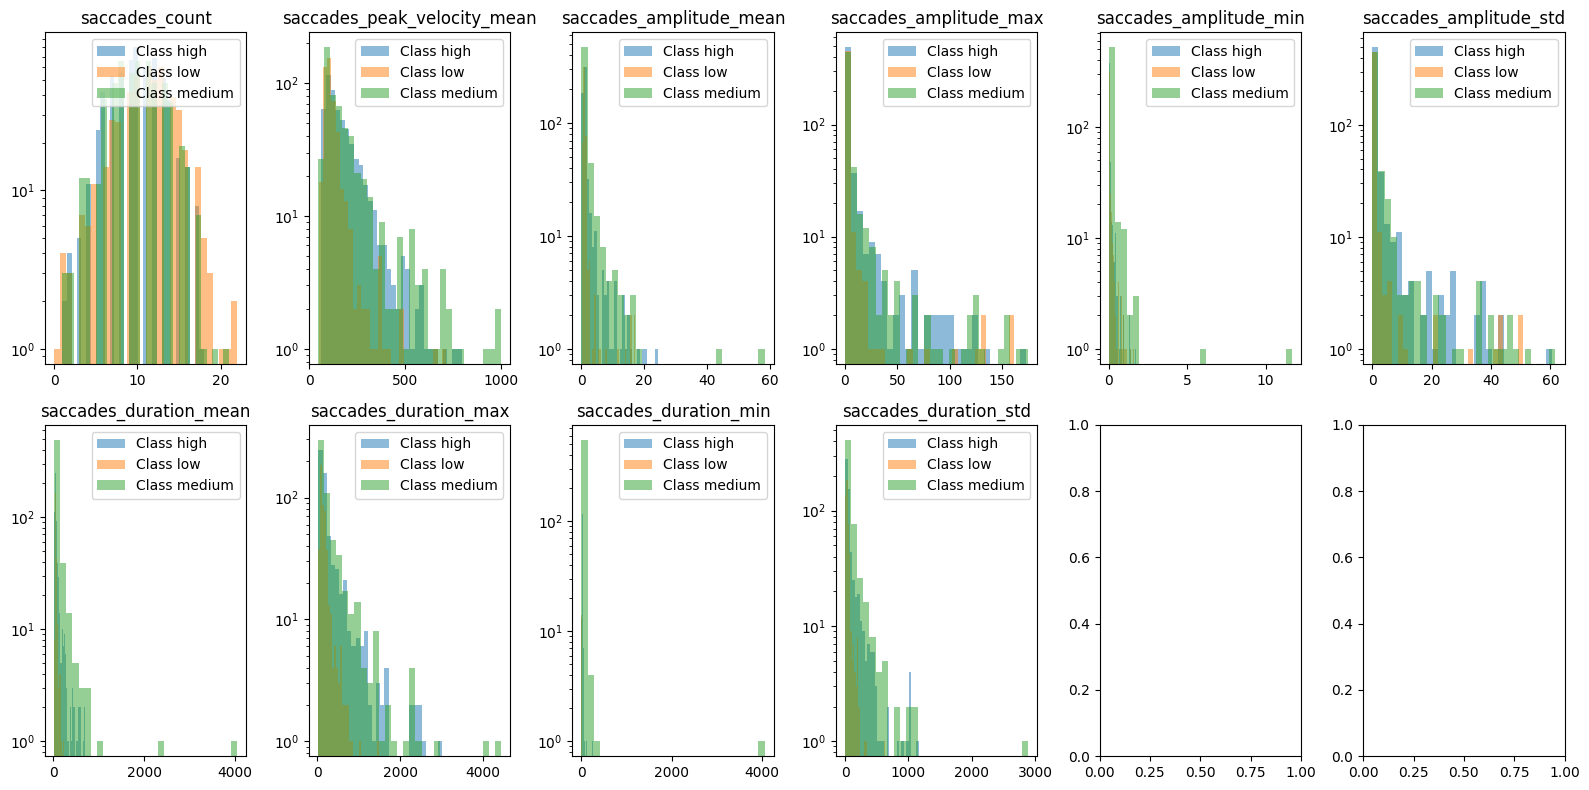

In [72]:
fixation_cols = [col for col in features_df.columns if col.startswith('saccades_')]
# Box plot for all fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    features_df.boxplot(column=col, by='cl_class', ax=axs[i], ylabel=col, xlabel='Cognitive Load Class', showfliers=False)
    axs[i].set_title(f'{col}')

# Also plot histograms of the fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    for cl_class, group in features_df.groupby('cl_class'):
        axs[i].hist(group[col], bins=30, alpha=0.5, label=f'Class {cl_class}', log=True)
    axs[i].set_title(f'{col}')
    axs[i].legend()

In [69]:
features_df_transformed.loc[features_df_transformed['fixations_duration_max'] > 1000, ['subject_id', 'task_id', 'fixations_duration_max']].sort_values(by='fixations_duration_max', ascending=False).head(10)

,subject_id,task_id,fixations_duration_max
1058,32,1,4617.59
1056,32,1,4467.56
67,3,1,4317.53
384,12,4,3967.46
1422,41,4,3684.07
496,14,4,3584.05
1370,41,1,3384.01
1065,32,1,3367.34
74,3,2,3334.00
1053,32,1,3283.99


In [78]:
features_df_transformed.loc[features_df_transformed['saccades_duration_max'] > 1000, ['subject_id', 'task_id']].value_counts()

subject_id  task_id
21          4          7
44          4          5
17          4          4
30          4          4
13          3          3
24          3          3
            4          3
25          3          3
36          3          3
5           4          2
14          4          2
15          4          2
20          3          2
28          4          2
31          4          2
40          3          2
            4          2
44          3          2
47          3          2
1           3          1
2           3          1
            4          1
3           4          1
9           3          1
11          4          1
12          4          1
17          3          1
19          3          1
20          4          1
27          3          1
29          4          1
36          4          1
37          4          1
43          3          1
46          3          1
            4          1
Name: count, dtype: int64

### TEMP

In [100]:
from sklearn import preprocessing
# z-normalize features
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now
# features_df_transformed.drop(columns=['pupil_lhipa'], inplace=True)
feature_cols = [col for col in features_df_transformed.columns if col not in ['subject_id', 'task_id', 'cl_class', 'bad_samples_ratio']]
# feature_cols = ['pupil_lhipa', 'pupil_ripa2', 'fixations_count', 'saccades_count']

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_skew,fixations_duration_kurt,fixations_duration_std,saccades_count,saccades_peak_velocity_min,saccades_peak_velocity_max,...,saccades_duration_kurt,saccades_duration_std,blinks_count,blinks_duration_max,blinks_duration_min,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id
count,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,...,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000
mean,20.411414,442.222804,1718.149561,74.322377,1.921057,4.337901,448.782979,19.658514,51.281849,287.631336,...,4.295539,50.366933,2.011916,111.922662,79.366764,4.472014,0.004250,6.034546,24.790216,2.757918
std,5.720822,189.699280,842.356499,35.526866,0.818298,4.463006,264.536535,5.757629,5.818212,135.267437,...,5.001752,47.731480,2.545788,97.506920,68.056648,0.520421,0.003789,7.013366,13.473645,1.089345
min,5.000000,154.576364,400.080000,50.010000,-0.466921,-2.625565,77.750578,4.000000,45.030536,67.880790,...,-3.333333,6.805499,0.000000,0.000000,0.000000,2.203232,0.000363,0.000000,1.000000,1.000000
25%,16.000000,322.731200,1133.560000,50.010000,1.335334,1.078491,279.806493,16.000000,47.627316,194.126578,...,0.322659,23.747653,0.000000,0.000000,0.000000,4.206170,0.001972,1.000000,13.000000,2.000000
50%,20.000000,397.698571,1533.640000,66.680000,1.801722,3.108900,382.905181,20.000000,49.595746,256.575006,...,3.067534,35.467033,1.000000,116.690000,100.020000,4.558674,0.003365,3.166667,24.000000,3.000000
75%,24.000000,508.925294,2067.080000,83.350000,2.397175,6.451581,532.613781,23.000000,52.975262,369.456303,...,7.022027,57.626665,3.000000,200.040000,116.690000,4.807052,0.005301,8.666667,38.000000,4.000000
max,41.000000,1947.056000,7884.910000,633.460000,5.043240,26.431348,3130.766245,40.000000,99.369781,1000.000000,...,30.276843,593.961686,17.000000,283.390000,283.390000,5.708374,0.043860,30.000000,47.000000,4.000000


In [ ]:
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn import svm, ensemble, neighbors

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
# Use cross-validation to create a validation set from the training set
cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=42)

print(f"Training set size: {len(train_x)}, Test set size: {len(test_x)}")

train_x_transformed = scaler.transform(train_x)
model = svm.LinearSVC()
# model = svm.NuSVC(nu=0.5, kernel='rbf', gamma='scale')
# model = neighbors.KNeighborsClassifier(n_neighbors=15)
# model = ensemble.RandomForestClassifier(n_estimators=5, random_state=42, max_depth=10)
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")
print("SVC coeffs classes:")
# coeffs = [pd.Series(model.coef_[i], index=feature_cols).sort_values(ascending=False) for i in range(len(model.coef_))]
# coeffs_df = pd.DataFrame({f'class_{i}': coeffs[i] for i in range(len(model.coef_))})
# display(coeffs_df)

Training set size: 2551, Test set size: 638
Train Accuracy: 0.79, Cross-validation Score: 0.64 (+/- 0.04)
SVC coeffs classes:


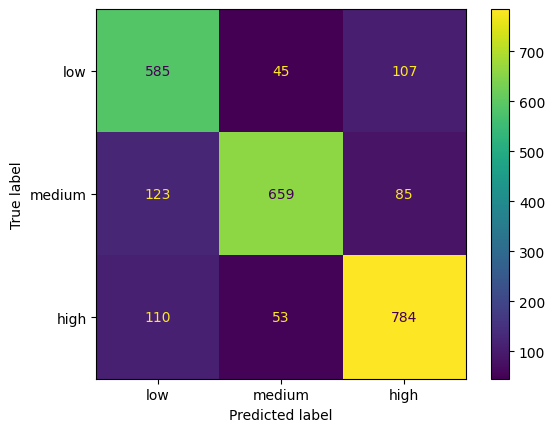

In [117]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_y_pred = model.predict(train_x_transformed)
cm = confusion_matrix(train_y, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()